In [7]:
import pandas as pd
pd.set_option('display.max_rows', 5)
import numpy as np
reviews = pd.read_csv("../input/wine-reviews/winemag-data-130k-v2.csv", index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '../input/wine-reviews/winemag-data-130k-v2.csv'

In [ ]:
reviews.points.describe()
reviews.points.mean()
reviews.taster_name.unique()
reviews.taster_name.value_counts()

> Walk me through how this code works. Line by line. What's lambda doing too?
    ▸ 📎 1 image(s) (61 KB)  (ctrl+o to expand)

▸ Thought for 2s
  Prioritizing Tool Usage
  Here is a line-by-line breakdown of what is happening in this code, including a deep dive into how lambda works.                                                                                            
                                                                                                                                                                                                              
  The overall goal of this code is to "mean-center" the data. It calculates the average score of all the wines, and then recalculates every individual wine's score to show how far above or below the average
  it is.                                                                                                                                                                                                      
                                                                                                                                                                                                              
  ### Line 1                                                                                                                                                                                                  
                                                                                                                                                                                                              
    review_points_mean = reviews.points.mean()                                                                                                                                                                
                                                                                                                                                                                                              
  • reviews.points: This selects the points column from the reviews DataFrame.                                                                                                                                
  • .mean(): This is a built-in pandas math function that calculates the mathematical average of all the numbers in that column.                                                                              
  • review_points_mean = ...: This takes that single average number (which happens to be roughly 88.4 based on the math in the image) and saves it into a variable so we can use it in the next step.         
                                                                                                                                                                                                              
  ### Line 2                                                                                                                                                                                                  
                                                                                                                                                                                                              
    reviews.points.map(lambda p: p - review_points_mean)                                                                                                                                                      
                                                                                                                                                                                                              
  • reviews.points: Again, we are looking at the points column.                                                                                                                                               
  • .map(...): The map function is a powerful tool. It says: "Take the function inside my parentheses, and apply it to every single value in this column, one by one, and give me back a new column with the  
  results."                                                                                                                                                                                                   
                                                                                                                                                                                                              
  ### What is lambda doing?                                                                                                                                                                                   
                                                                                                                                                                                                              
  A lambda is Python's way of writing a quick, throwaway function on a single line without needing to formally define it using def my_function():. It is also called an "anonymous function."                 
                                                                                                                                                                                                              
  Let's break down lambda p: p - review_points_mean:                                                                                                                                                          
                                                                                                                                                                                                              
  1. lambda: This keyword tells Python, "I'm writing a mini-function right now."                                                                                                                              
  2. p: This is the input variable for the function. Because this lambda is inside a .map(), pandas is going to grab the first row's point value (e.g., 87) and pass it into the lambda as p. You can name    
  this whatever you want (x, value, score), but p makes sense for "points".                                                                                                                                   
  3. :: The colon separates the inputs from the math/logic you want to perform.                                                                                                                               
  4. p - review_points_mean: This is the return value. It takes the current row's value (p) and subtracts the overall average we calculated in line 1.                                                        
                                                                                                                                                                                                              
  How they work together:                                                                                                                                                                                     
  Under the hood, pandas .map() acts like a loop.                                                                                                                                                             
                                                                                                                                                                                                              
  • It grabs row 0 (let's say the wine scored 87). It passes 87 into the lambda as p. The lambda calculates 87 - 88.447 and outputs -1.447.                                                                   
  • It grabs row 1 (also an 87). It outputs -1.447.                                                                                                                                                           
  • It does this for all 129,971 rows in a fraction of a second, resulting in the new Series you see in the Out[8] box!                                                                                       


In [ ]:
def remean_points(row):
    row.points = row.points - review_points_mean
    return row

reviews.apply(remean_points, axis='columns')

> Tell me how this code works
    ▸ 📎 1 image(s) (64 KB)  (ctrl+o to expand)

▸ Thought for 3s
  Prioritizing Tool Usage
  Here is a step-by-step breakdown of how this code works.                                                                                                                                                    
                                                                                                                                                                                                              
  While the previous example used .map() to transform a single column, this code uses .apply() to transform an entire DataFrame by operating on it row-by-row.                                                
                                                                                                                                                                                                              
  ### Step 1: Defining the Custom Function                                                                                                                                                                    
                                                                                                                                                                                                              
    def remean_points(row):                                                                                                                                                                                   
        row.points = row.points - review_points_mean                                                                                                                                                          
        return row                                                                                                                                                                                            
                                                                                                                                                                                                              
  Here, you are creating a standard Python function named remean_points.                                                                                                                                      
                                                                                                                                                                                                              
  • row (the input): Because we will use this function with pandas .apply(), we design it to expect a single row of data (which pandas treats as a Series).                                                   
  • row.points = ...: It looks inside that row, finds the points value, subtracts the overall average (review_points_mean), and updates the row's points value with the new number.                           
  • return row: It hands the modified row back.                                                                                                                                                               
                                                                                                                                                                                                              
  ### Step 2: Applying the Function                                                                                                                                                                           
                                                                                                                                                                                                              
    reviews.apply(remean_points, axis='columns')                                                                                                                                                              
                                                                                                                                                                                                              
  • reviews.apply(...): The .apply() method takes a function and runs it across the DataFrame. Notice that we pass remean_points without parentheses. We are handing the function itself to pandas so pandas  
  can run it.                                                                                                                                                                                                 
  • axis='columns': This is the secret sauce. By default, .apply() passes entire columns into your function one by one. By setting axis='columns' (which can also be written as axis=1), we tell pandas: "Pass
  the data into my function as horizontal rows, one at a time."                                                                                                                                               
                                                                                                                                                                                                              
  ### How they work together:                                                                                                                                                                                 
                                                                                                                                                                                                              
  Behind the scenes, pandas grabs Row 0 and passes it to remean_points(). The function adjusts the score and returns the row. Pandas then grabs Row 1, does the same thing, and repeats this for all 130,000  
  rows. Finally, it stitches all the updated rows back together into the brand new DataFrame you see in the output!                                                                                           
  ──────                                                                                                                                                                                                      
  ### 🚀 Optimization Note (Keeping efficiency in mind!)                                                                                                                                                      
                                                                                                                                                                                                              
  Since you asked me to keep software engineering efficiency in mind, I have to point out a major Execution Speed caveat with this specific code block!                                                       
                                                                                                                                                                                                              
  Using .apply() with axis='columns' (row-by-row) is very slow in pandas because it forces the computer to run a standard Python loop over every single row.                                                  
                                                                                                                                                                                                              
  A much faster, memory-efficient way to do this exact same thing using "vectorization" (which allows pandas to do the math on the whole column simultaneously in C) is:                                      
                                                                                                                                                                                                              
    reviews.points = reviews.points - review_points_mean                                                                                                                                                      
                                                                                                                                                                                                              
  This one-liner achieves the exact same result as the .apply() method shown in the tutorial, but will run hundreds of times faster on large datasets!***          

In [ ]:
# Pandas provides many common mapping operations as built-ins. For example, here's a faster way of remeaning our points column:
review_points_mean = reviews.points.mean()
reviews.points - review_points_mean

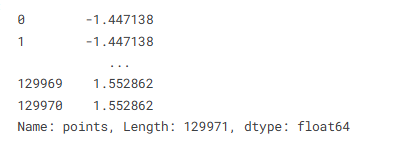
In this code we are performing an operation between a lot of values on the left-hand side (everything in the Series) and a single value on the right-hand side (the mean value). Pandas looks at this expression and figures out that we must mean to subtract that mean value from every value in the dataset.

Pandas will also understand what to do if we perform these operations between Series of equal length. For example, an easy way of combining country and region information in the dataset would be to do the following:

In [ ]:
reviews.country + " - " + reviews.region_1

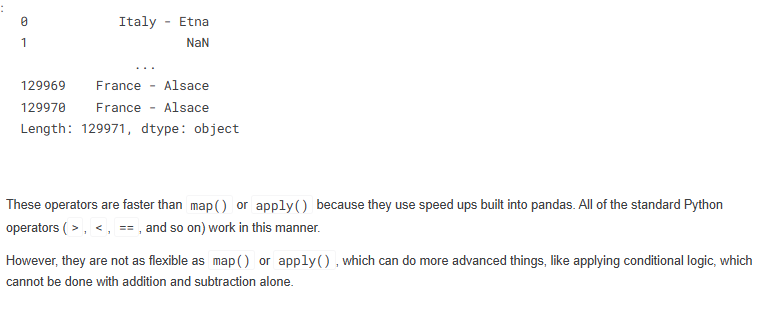